# ALSSM Trajectory [ex102.0]

Evaluation of an **ALSSM** (Autonomous Linear State Space Model) over a time range given an initial state $x_0$.

## Concept

An ALSSM generates an output signal $s_j(x_0)$ by propagating an initial state $x_0$ forward through the state transition matrix $A$:

$$s_j(x_0) = C A^j x_0, \quad j \in \mathbb{Z}$$

where:
- $A \in \mathbb{R}^{N \times N}$ — state transition matrix
- $C \in \mathbb{R}^{Q \times N}$ — output matrix
- $x_0 \in \mathbb{R}^N$ — initial state vector
- $j$ — evaluation index (time offset)

> **Paper ref:** Wildhaber et al. (2018), §2 "ALSSM Signal Model", Eq. (1)

For polynomial ALSSMs (`AlssmPoly`), $A$ is the Pascal/binomial matrix and $C = [1, 0, \ldots, 0]$, encoding a polynomial of degree $N-1$.

In [1]:
import matplotlib.pyplot as plt
import lmlib as lm

## Define evaluation range

$j \in [-20, 20)$ is the range of time indices at which we evaluate the ALSSM output.

In [2]:
js = range(-20, 20)  # ALSSM evaluation range

## 1st-degree polynomial ALSSM (linear signal)

`poly_degree=1` → $N=2$, state $\mathbf{x_0} = [x_0, x_1]^\top$, output $s_j = x_0 + x_1 \cdot j$

Initial state $\mathbf{x_0} = [-1,\ 2]^\top$ encodes: $s_0 = -1$, slope $= 2$.

In [3]:
alssm_d1 = lm.AlssmPoly(poly_degree=1, label='1st degree')
x0_d1 = [-1, 2]
sx0_d1 = alssm_d1.eval_output(x0_d1, js)

print('A =\n', alssm_d1.A)
print('C =', alssm_d1.C)

A =
 [[1 1]
 [0 1]]
C = [1 0]


## 2nd-degree polynomial ALSSM (quadratic signal)

`poly_degree=2` → $N=3$, state $\mathbf{x_0} = [x_0, x_1, x_2]^\top$, output $s_j = x_0 + x_1 j + x_2 j^2$

In [4]:
alssm_d2 = lm.AlssmPoly(poly_degree=2, label='2nd degree')
x0_d2 = [-1, 2, .1]
sx0_d2 = alssm_d2.eval_output(x0_d2, js)

## 3rd-degree polynomial ALSSM (cubic signal)

`poly_degree=3` → $N=4$, state $\mathbf{x_0} = [x_0, x_1, x_2, x_3]^\top$

In [5]:
alssm_d3 = lm.AlssmPoly(poly_degree=3, label='3rd degree')
x0_d3 = [-1, 2, .1, -.01]
sx0_d3 = alssm_d3.eval_output(x0_d3, js)

## Inspect model internals

`dump_tree()` shows the model's matrix structure.  
Verify that $A$ is the upper-triangular Pascal matrix (binomial coefficients) and $C = [1, 0, \ldots, 0]$.

In [6]:
print('--DUMP--\n', alssm_d3.dump_tree())
print('\n--REPR--\n', alssm_d3)

--DUMP--
 └-AlssmPoly, A: (4, 4), C: (4,), label: 3rd degree

--REPR--
 AlssmPoly(A=[[1 1 1 1] [0 1 2 3] [0 0 1 3] [0 0 0 1]], C=[1 0 0 0], label=3rd degree)


## Plot trajectories

Each curve $s_j(\mathbf{x_0}) = C A^j \mathbf{x_0}$ is a polynomial of the indicated degree, evaluated at each $j$ in the range.

**Key observation:** The choice of $\mathbf{x_0}$ sets the value and all derivatives at $j=0$.  
The farther $j$ departs from 0, the more the highest-degree term dominates.

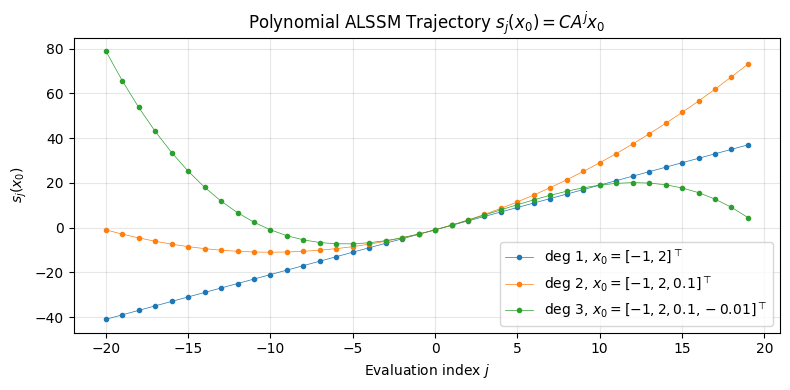

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(js, sx0_d1, '.-', lw=.5, label=r'deg 1, $x_0 = ' + str(x0_d1) + r'^\top$')
plt.plot(js, sx0_d2, '.-', lw=.5, label=r'deg 2, $x_0 = ' + str(x0_d2) + r'^\top$')
plt.plot(js, sx0_d3, '.-', lw=.5, label=r'deg 3, $x_0 = ' + str(x0_d3) + r'^\top$')
plt.xlabel('Evaluation index $j$')
plt.ylabel('$s_j(x_0)$')
plt.title('Polynomial ALSSM Trajectory $s_j(x_0) = C A^j x_0$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Concept | Code | Paper |
|---|---|---|
| ALSSM signal model $s_j(\mathbf{x_0}) = CA^j \mathbf{x_0}$ | `AlssmPoly`, `eval_output` | Wildhaber2018, Eq. (1) |
| Polynomial $A$ (Pascal matrix) | `AlssmPoly(poly_degree=n)` | Wildhaber2018, §2.1 |
| State vector $\mathbf{x_0}$ encodes polynomial coefficients | `x_0 = [x0, x1, ...]` | Wildhaber2018, §2.1 |

**Next:** `example-ex103.0-cost-segment` — wrap this model in a windowed cost function.